In [1]:
from mpramnist.Arensbergen2019.dataset import ArensbergenDataset
from mpramnist.Arensbergen2019.trainer import LitModel_Arensbergen_Reg
from mpramnist.Arensbergen2019.trainer import LitModel_Arensbergen_Clas

from mpramnist.models import HumanLegNet
from mpramnist.models import initialize_weights

from mpramnist import transforms as t

import torch
import torch.nn as nn
import lightning.pytorch as L
import torch.utils.data as data

from torchmetrics import PearsonCorrCoef

from torch.nn.utils.rnn import pad_sequence

/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Preprocessing
train_transform = t.Compose([t.ReverseComplement(0.5),t.Seq2Tensor(sequence_first=True),])
test_transform = t.Compose([t.Seq2Tensor(sequence_first=True),])

# Sequences in each batch are padded with "N" nucleotides 
# to match the length of the longest sequence in the batch
# However, to enable this function to work properly, 
# the shape of sequence tensors needs to be changed, 
# which is achieved by setting the `t.Seq2Tensor(sequence_first=True)`
def make_pad_collate(channels_last: bool):
    """Build a collate function that pads variable-length sequences.

    `Seq2Tensor(sequence_first=True)` is used in this file,
    because `pad_sequence` pads along the first dimension
    of each tensor and that must be the length axis `L`, giving individual
    sequences shape `(L, C)`. After padding, the batch is `(B, L, C)`
    (channels-last).

    Almost all models here expect channels-first `(B, C, L)`, so this collate
    transposes the padded batch back unless `channels_last` is True.
    """

    def collate(batch):
        seq, targets = zip(*batch)
        seq = pad_sequence(seq, batch_first=True, padding_value=0.25)  # (B, L, C)
        if not channels_last:
            seq = seq.transpose(1, 2).contiguous()  # (B, C, L)
        return seq, torch.vstack(targets)

    return collate

In [3]:
print("GENOME_IDS", ArensbergenDataset.GENOME_IDS)
print("CELL_TYPES", ArensbergenDataset.CELL_TYPES)

GENOME_IDS ['SuRE42_HG02601', 'SuRE43_GM18983', 'SuRE44_HG01241', 'SuRE45_HG03464']
CELL_TYPES ['K562', 'HepG2']


# Classification

In [4]:
task = "classification"
cell_types = ['K562', 'HepG2']
BATCH_SIZE = 1024
NUM_WORKERS = 16
channels_last = False

# load the data
train_dataset = ArensbergenDataset(task=task, cell_type=cell_types, genome_id=['SuRE42_HG02601', 'SuRE43_GM18983'], split="train", transform=train_transform, root="../data/",)
val_dataset =  ArensbergenDataset(task=task, cell_type=cell_types, genome_id=['SuRE42_HG02601', 'SuRE43_GM18983'], split="val", transform=test_transform, root="../data/",)
test_dataset = ArensbergenDataset(task=task, cell_type=cell_types, genome_id=['SuRE42_HG02601', 'SuRE43_GM18983'], split="test", transform=test_transform, root="../data/",)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=make_pad_collate(channels_last))
val_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=make_pad_collate(channels_last))
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=make_pad_collate(channels_last))

N_CLASSES = 5*len(cell_types) # each cell type have 5 bins
sample_seq = train_dataset[0][0]
in_channels = len(sample_seq[0])

After filtering duplicates: 145627 sequences in val
After filtering duplicates: 145652 sequences in test


In [5]:
sample_seq.shape

torch.Size([196, 4])

In [6]:
model = HumanLegNet(
    in_ch=in_channels,
    output_dim=N_CLASSES,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[80, 96, 112, 128],
    pool_sizes=[2, 2, 2, 2],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Arensbergen_Clas(
    model=model,
    loss=nn.CrossEntropyLoss(),
    n_classes=N_CLASSES,
    weight_decay=1e-2,
    lr=5e-3,
    print_each=10,
)

In [7]:
# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=1,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
)

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | HumanLegNet      | 1.3 M  | train
1 | loss  | CrossEntropyLoss | 0      | train
---------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.299     Total estimated model params size (MB)
117       Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 1147/1147 [02:48<00:00,  6.79it/s, v_num=68, train_loss_step=2.820, val_loss=2.990, train_loss_epoch=2.920]

Metric val_loss improved. New best score: 2.995
`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 1147/1147 [02:49<00:00,  6.78it/s, v_num=68, train_loss_step=2.820, val_loss=2.990, train_loss_epoch=2.920]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing DataLoader 0: 100%|██████████| 143/143 [00:04<00:00, 29.14it/s]
----------------------------------------------------------------------------------------------------
| HepG2: || Precision: 0.32461 | Recall: 0.32131 | Accuracy: 0.32544 | F1: 0.28096 | Val_AUCROC: 0.67098 | Val_AUPR: 0.32557 |
----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------
| K562: || Precision: 0.28461 | Recall: 0.31261 | Accuracy: 0.31870 | F1: 0.26147 | Val_AUCROC: 0.64927 | Val_AUPR: 0.30544 |
----------------------------------------------------------------------------------------------------



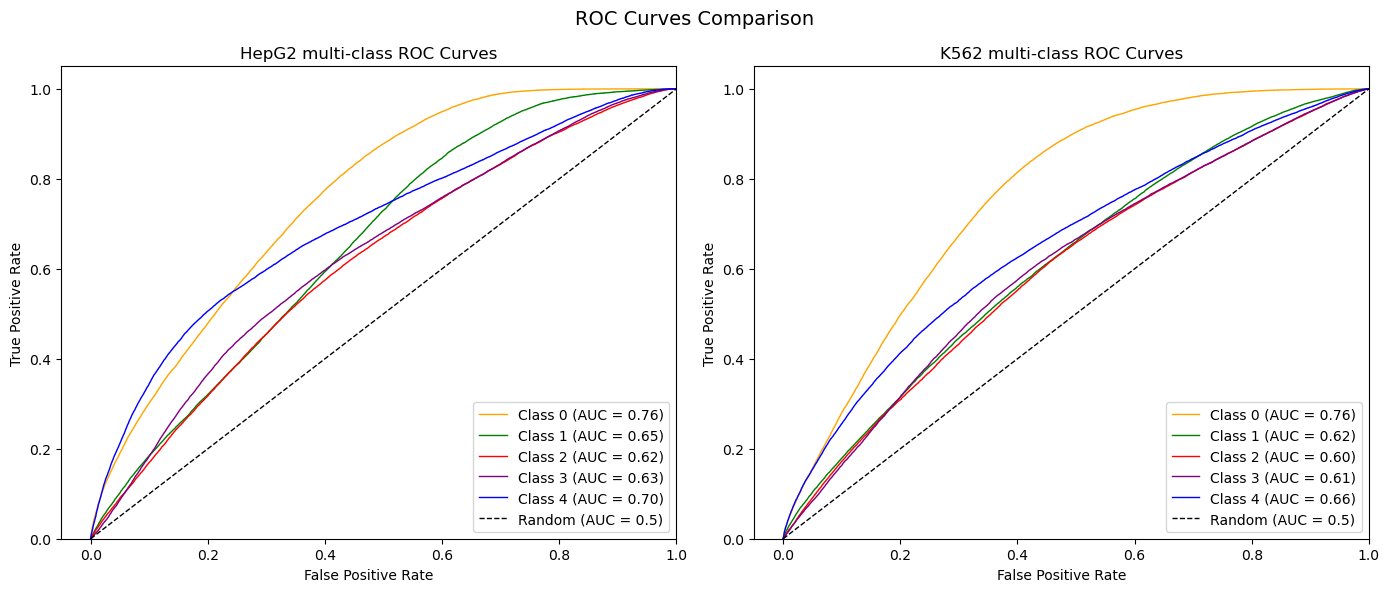

Testing DataLoader 0: 100%|██████████| 143/143 [00:06<00:00, 22.29it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss            2.994805335998535
     val_HepG2_aupr         0.3255719840526581
     val_HepG2_auroc        0.6709797978401184
      val_HepG2_f1          0.28096088767051697
      val_K562_aupr         0.30544230341911316
     val_K562_auroc         0.6492656469345093
       val_K562_f1          0.26146745681762695
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 2.994805335998535,
  'val_HepG2_auroc': 0.6709797978401184,
  'val_HepG2_aupr': 0.3255719840526581,
  'val_HepG2_f1': 0.28096088767051697,
  'val_K562_auroc': 0.6492656469345093,
  'val_K562_aupr': 0.30544230341911316,
  'val_K562_f1': 0.26146745681762695}]

In [8]:
# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)

# Regression

In [9]:
forw_transform = t.Compose([t.Seq2Tensor(sequence_first=True)])
rev_transform = t.Compose([t.ReverseComplement(1),t.Seq2Tensor(sequence_first=True)])

def meaned_prediction(forw, rev, trainer, seq_model, name, num):
    predictions_forw = trainer.predict(seq_model, dataloaders=forw)
    targets = torch.cat([pred["target"] for pred in predictions_forw])
    y_preds_forw = torch.cat([pred["predicted"] for pred in predictions_forw])

    predictions_rev = trainer.predict(seq_model, dataloaders=rev)
    y_preds_rev = torch.cat([pred["predicted"] for pred in predictions_rev])

    mean_forw = torch.mean(torch.stack([y_preds_forw, y_preds_rev]), dim=0)

    pears = PearsonCorrCoef(num_outputs=num)
    print(name, " Pearson correlation")

    return pears(mean_forw, targets)

In [10]:
task = "regression"
cell_types = ["HepG2", "K562"]
BATCH_SIZE = 1024
NUM_WORKERS = 16
channels_last = False

# load the data
train_dataset = ArensbergenDataset(task=task,cell_type=cell_types, genome_id=['SuRE42_HG02601', 'SuRE43_GM18983'], split="train", transform=train_transform, root="../data/",)
val_dataset = ArensbergenDataset(task=task,cell_type=cell_types, genome_id=['SuRE42_HG02601', 'SuRE43_GM18983'], split="val", transform=test_transform, root="../data/",)
test_dataset = ArensbergenDataset(task=task,cell_type=cell_types, genome_id=['SuRE42_HG02601', 'SuRE43_GM18983'], split="test", transform=test_transform, root="../data/",)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=make_pad_collate(channels_last))
val_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=make_pad_collate(channels_last))
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=make_pad_collate(channels_last))

num_outputs = len(cell_types)
sample_seq = train_dataset[0][0]
in_channels = len(sample_seq[0])

After filtering duplicates: 145627 sequences in val
After filtering duplicates: 145652 sequences in test


In [11]:
model = HumanLegNet(
    in_ch=in_channels,
    output_dim=num_outputs,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[80, 96, 112, 128],
    pool_sizes=[2, 2, 2, 2],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Arensbergen_Reg(
    model=model,
    cell_types=cell_types,
    loss=nn.MSELoss(),
    weight_decay=1e-2,
    lr=5e-3,
    print_each=25,
)

In [12]:
# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=1,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
    enable_model_summary=False,
)

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [13]:
# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.


Epoch 0:   0%|          | 2/1147 [00:00<07:25,  2.57it/s, v_num=69, train_loss_step=685.0]

/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 0: 100%|██████████| 1147/1147 [02:48<00:00,  6.80it/s, v_num=69, train_loss_step=309.0, val_loss=542.0, val_HepG2_pearson=0.159, val_K562_pearson=0.379, val_pearson=0.269, train_loss_epoch=443.0]

/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The variance of predictions or target is close to zero. This can cause instability in Pearson correlationcoefficient, leading to wrong results. Consider re-scaling the input if possible or computing using alarger dtype (currently using torch.float32). Setting the correlation coefficient to nan.
  warnings.warn(*args, **kwargs)
Metric val_loss improved. New best score: 542.220
`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 1147/1147 [02:48<00:00,  6.80it/s, v_num=69, train_loss_step=309.0, val_loss=542.0, val_HepG2_pearson=0.159, val_K562_pearson=0.379, val_pearson=0.269, train_loss_epoch=443.0]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing DataLoader 0: 100%|██████████| 143/143 [00:05<00:00, 28.45it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   test_HepG2_pearson       0.15904536843299866
    test_K562_pearson       0.3785339295864105
        test_loss             542.2197265625
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 542.2197265625,
  'test_HepG2_pearson': 0.15904536843299866,
  'test_K562_pearson': 0.3785339295864105}]

In [15]:
test_forw = ArensbergenDataset(task=task, cell_type=cell_types, genome_id=['SuRE42_HG02601', 'SuRE43_GM18983'], split="test", transform=forw_transform, root="../data/",)
test_rev = ArensbergenDataset(task=task, cell_type=cell_types, genome_id=['SuRE42_HG02601', 'SuRE43_GM18983'], split="test", transform=rev_transform, root="../data/",)

forw = data.DataLoader(dataset=test_forw, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=make_pad_collate(channels_last))
rev = data.DataLoader(dataset=test_rev, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=make_pad_collate(channels_last))

meaned_prediction(forw, rev, trainer, seq_model, cell_types, len(cell_types))

After filtering duplicates: 145652 sequences in test
After filtering duplicates: 145652 sequences in test


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting DataLoader 0: 100%|██████████| 143/143 [00:05<00:00, 27.94it/s]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting DataLoader 0: 100%|██████████| 143/143 [00:05<00:00, 27.80it/s]
['HepG2', 'K562']  Pearson correlation


tensor([0.1645, 0.3812])